In [1]:
# ============ NER FROM SCRATCH ============

def implement_ner_from_scratch():
    """
    Build a simple NER system from scratch (No libraries!)
    """
    
    print("="*70)
    print("NER FROM SCRATCH - BUILD YOUR OWN")
    print("="*70)
    
    # ============ STEP 1: CREATE A SIMPLE RULE-BASED NER ============
    print("\n Creating a Rule-Based NER System")
    print("-" * 40)
    
    class SimpleNER:
        """
        A very simple NER system using rules
        This is how NER started before machine learning!
        """
        
        def __init__(self):
            # Person names dictionary
            self.person_names = {
                'elon', 'musk', 'steve', 'jobs', 'tim', 'cook',
                'bill', 'gates', 'jeff', 'bezos', 'mark', 'zuckerberg',
                'sundar', 'pichai', 'satya', 'nadella', 'warren', 'buffett'
            }
            
            # Organization names
            self.organizations = {
                'google', 'apple', 'microsoft', 'amazon', 'tesla',
                'spacex', 'facebook', 'meta', 'netflix', 'openai',
                'nasa', 'nato', 'united', 'nations', 'world', 'bank'
            }
            
            # Location names
            self.locations = {
                'california', 'new york', 'london', 'paris', 'tokyo',
                'china', 'india', 'usa', 'uk', 'france', 'germany',
                'australia', 'canada', 'brazil', 'mexico', 'italy'
            }
            
            # Date patterns
            self.date_patterns = [
                r'\d{1,2}/\d{1,2}/\d{4}',  # 12/25/2024
                r'\d{4}-\d{2}-\d{2}',       # 2024-12-25
                r'[A-Z][a-z]+ \d{1,2}, \d{4}',  # December 25, 2024
                r'\d{1,2}[a-z]{2} [A-Z][a-z]+ \d{4}'  # 25th December 2024
            ]
            
            # Money patterns
            self.money_patterns = [
                r'\$\d+(?:,\d{3})*',      # $1,000
                r'\$\d+\.\d{2}',          # $99.99
                r'\d+ dollars',            # 100 dollars
                r'\d+ million',            # 10 million
                r'\d+ billion'             # 5 billion
            ]
        
        def detect_entities(self, text):
            """
            Detect entities using rules
            """
            entities = []
            
            # Split into words
            words = text.lower().split()
            i = 0
            
            while i < len(words):
                word = words[i]
                original_word = text.split()[i]
                
                # Check for person (two words)
                if i + 1 < len(words):
                    full_name = f"{word} {words[i+1]}"
                    if word in self.person_names and words[i+1] in self.person_names:
                        entities.append({
                            'text': f"{original_word} {text.split()[i+1]}",
                            'type': 'PERSON',
                            'start': i,
                            'end': i + 2
                        })
                        i += 2
                        continue
                
                # Check for person (single)
                if word in self.person_names:
                    entities.append({
                        'text': original_word,
                        'type': 'PERSON',
                        'start': i,
                        'end': i + 1
                    })
                    i += 1
                    continue
                
                # Check for organization (multi-word)
                org_parts = []
                j = i
                while j < len(words):
                    if words[j] in self.organizations:
                        org_parts.append(text.split()[j])
                        j += 1
                    else:
                        break
                
                if len(org_parts) >= 1:
                    entities.append({
                        'text': ' '.join(org_parts),
                        'type': 'ORGANIZATION',
                        'start': i,
                        'end': j
                    })
                    i = j
                    continue
                
                # Check for location (multi-word)
                loc_parts = []
                j = i
                while j < len(words):
                    if words[j] in self.locations:
                        loc_parts.append(text.split()[j])
                        j += 1
                    else:
                        break
                
                if len(loc_parts) >= 1:
                    entities.append({
                        'text': ' '.join(loc_parts),
                        'type': 'LOCATION',
                        'start': i,
                        'end': j
                    })
                    i = j
                    continue
                
                i += 1
            
            return entities
    
    # ============ TEST THE NER ============
    print("\n Testing Our NER System")
    print("-" * 40)
    
    ner = SimpleNER()
    
    test_texts = [
        "Elon Musk founded SpaceX in California.",
        "Tim Cook is the CEO of Apple.",
        "Satya Nadella runs Microsoft in Washington.",
        "Jeff Bezos started Amazon in Seattle."
    ]
    
    for text in test_texts:
        print(f"\n Text: {text}")
        print(f"\n Entities Found:")
        
        entities = ner.detect_entities(text)
        if entities:
            for entity in entities:
                print(f"   • {entity['text']}: {entity['type']}")
        else:
            print("   No entities found")
    
    # ============ COMPARE WITH SPACY ============
    print("\n Comparing with Professional NER (spaCy)")
    print("-" * 40)
    
    try:
        import spacy
        
        print("\n   Loading spaCy model...")
        nlp = spacy.load("en_core_web_sm")
        
        test_text = "Elon Musk founded SpaceX in California."
        print(f"\n   Text: {test_text}")
        
        doc = nlp(test_text)
        print(f"\n   spaCy Results:")
        for ent in doc.ents:
            print(f"   • {ent.text}: {ent.label_}")
            
        print("\n   Differences:")
        print("   • Our NER: Rule-based (simple but works)")
        print("   • spaCy NER: Machine learning (more accurate)")
        print("   • Our NER: Can't handle unknown names")
        print("   • spaCy NER: Learns from data")
        
    except ImportError:
        print("    spaCy not installed. Install with: pip install spacy")
        print("   Then: python -m spacy download en_core_web_sm")

# Run the NER implementation
implement_ner_from_scratch()

NER FROM SCRATCH - BUILD YOUR OWN

 Creating a Rule-Based NER System
----------------------------------------

 Testing Our NER System
----------------------------------------

 Text: Elon Musk founded SpaceX in California.

 Entities Found:
   • Elon Musk: PERSON
   • SpaceX: ORGANIZATION

 Text: Tim Cook is the CEO of Apple.

 Entities Found:
   • Tim Cook: PERSON

 Text: Satya Nadella runs Microsoft in Washington.

 Entities Found:
   • Satya Nadella: PERSON
   • Microsoft: ORGANIZATION

 Text: Jeff Bezos started Amazon in Seattle.

 Entities Found:
   • Jeff Bezos: PERSON
   • Amazon: ORGANIZATION

 Comparing with Professional NER (spaCy)
----------------------------------------

   Loading spaCy model...

   Text: Elon Musk founded SpaceX in California.

   spaCy Results:
   • Elon Musk: PERSON
   • California: GPE

   Differences:
   • Our NER: Rule-based (simple but works)
   • spaCy NER: Machine learning (more accurate)
   • Our NER: Can't handle unknown names
   • spaCy NER: L

In [2]:
# ============ NER WITH HUGGINGFACE ============

def huggingface_ner_complete():
    """
    Using HuggingFace for NER (Noob-Friendly)
    """
    
    print("="*70)
    print("NER WITH HUGGINGFACE - THE EASY WAY")
    print("="*70)
    
    try:
        from transformers import pipeline
        
        print("\n Loading NER Pipeline...")
        print("   (This is a pre-trained model that knows how to find entities)")
        
        # Load the NER pipeline
        ner = pipeline(
            "ner",
            model="dbmdz/bert-large-cased-finetuned-conll03-english",
            aggregation_strategy="simple"  # Groups tokens together
        )
        
        print("    Model loaded successfully!")
        
        # ============ EXAMPLE 1: SIMPLE TEXT ============
        print("\n Example 1: Simple Text")
        print("-" * 40)
        
        text1 = "Apple CEO Tim Cook visited India last week."
        print(f"Text: {text1}")
        
        results = ner(text1)
        print("\n Entities Found:")
        for entity in results:
            print(f"   • {entity['word']}: {entity['entity_group']} (Score: {entity['score']:.3f})")
        
        # ============ EXAMPLE 2: COMPLEX TEXT ============
        print("\n Example 2: Complex Text")
        print("-" * 40)
        
        text2 = """
        Tesla CEO Elon Musk announced the new Cybertruck at their 
        headquarters in Austin, Texas. The vehicle costs $39,900 
        and will be available starting December 2024.
        """
        print(f"Text: {text2}")
        
        results = ner(text2)
        print("\n Entities Found:")
        for entity in results:
            print(f"   • {entity['word']}: {entity['entity_group']} (Score: {entity['score']:.3f})")
        
        # ============ EXAMPLE 3: DIFFERENT TYPES ============
        print("\n Example 3: Different Entity Types")
        print("-" * 40)
        
        text3 = """
        Microsoft's Satya Nadella announced a $50 billion investment 
        in AI research. The project will create 10,000 new jobs and 
        is expected to grow revenue by 25% in 2024.
        """
        print(f"Text: {text3}")
        
        results = ner(text3)
        print("\n Entities Found:")
        for entity in results:
            print(f"   • {entity['word']}: {entity['entity_group']} (Score: {entity['score']:.3f})")
        
        # ============ VISUAL ENTITY MAP ============
        print("\n Entity Visualization")
        print("-" * 40)
        
        def visualize_entities(text, entities):
            """
            Visualize entities with colors
            """
            # Color mapping
            colors = {
                'PER': '\033[94m',  # Blue - Person
                'ORG': '\033[92m',  # Green - Organization
                'LOC': '\033[93m',  # Yellow - Location
                'MISC': '\033[95m', # Magenta - Miscellaneous
                'DATE': '\033[96m', # Cyan - Date
                'MONEY': '\033[91m' # Red - Money
            }
            reset = '\033[0m'
            
            # Create entity map
            entity_map = {}
            for entity in entities:
                entity_map[entity['word']] = entity['entity_group']
            
            # Color the text
            words = text.split()
            colored_words = []
            
            for word in words:
                # Remove punctuation for matching
                clean_word = word.strip('.,!?')
                if clean_word in entity_map:
                    color = colors.get(entity_map[clean_word], reset)
                    colored_words.append(f"{color}{word}{reset}")
                else:
                    colored_words.append(word)
            
            return ' '.join(colored_words)
        
        print("\n   Colored Entity Visualization:")
        print("   " + "-" * 30)
        
        entities = ner(text2)
        colored_text = visualize_entities(text2, entities)
        print(f"   {colored_text}")
        print("\n   Legend:")
        print("   🔵 Blue = PERSON")
        print("   🟢 Green = ORGANIZATION")
        print("   🟡 Yellow = LOCATION")
        print("   🔴 Red = MONEY")
        print("   🟣 Magenta = MISCELLANEOUS")
        print("   🩵 Cyan = DATE")
        
        # ============ BATCH PROCESSING ============
        print("\n Batch Processing Multiple Texts")
        print("-" * 40)
        
        texts = [
            "Google's Sundar Pichai attended the conference in London.",
            "Amazon acquired a company for $1.5 billion.",
            "NASA launched a rocket from Cape Canaveral.",
            "Queen Elizabeth visited Australia in 2011."
        ]
        
        for i, text in enumerate(texts, 1):
            print(f"\n   Text {i}: {text}")
            entities = ner(text)
            if entities:
                print("   Entities:")
                for entity in entities[:3]:  # Show top 3
                    print(f"   • {entity['word']}: {entity['entity_group']}")
            else:
                print("   No entities found")
        
    except ImportError:
        print("❌ Transformers not installed. Install with: pip install transformers")
    except Exception as e:
        print(f"❌ Error: {e}")

# Run the complete NER with HuggingFace
huggingface_ner_complete()

NER WITH HUGGINGFACE - THE EASY WAY



 Loading NER Pipeline...
   (This is a pre-trained model that knows how to find entities)


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

    Model loaded successfully!

 Example 1: Simple Text
----------------------------------------
Text: Apple CEO Tim Cook visited India last week.

 Entities Found:
   • Apple: ORG (Score: 0.998)
   • Tim Cook: PER (Score: 1.000)
   • India: LOC (Score: 1.000)

 Example 2: Complex Text
----------------------------------------
Text: 
        Tesla CEO Elon Musk announced the new Cybertruck at their 
        headquarters in Austin, Texas. The vehicle costs $39,900 
        and will be available starting December 2024.
        

 Entities Found:
   • Tesla: ORG (Score: 0.992)
   • Elon Musk: PER (Score: 0.998)
   • Cybertruck: MISC (Score: 0.933)
   • Austin: LOC (Score: 0.998)
   • Texas: LOC (Score: 1.000)

 Example 3: Different Entity Types
----------------------------------------
Text: 
        Microsoft's Satya Nadella announced a $50 billion investment 
        in AI research. The project will create 10,000 new jobs and 
        is expected to grow revenue by 25% in 2024.
        



In [3]:
# ============================================
# DAY 1: NAMED ENTITY RECOGNITION (NER) PRACTICE
# Tech Prime Pvt Limited - Advanced AI/ML Internship
# ============================================

# This notebook covers:
# 1. Understanding NER and BIO tagging
# 2. Rule-based NER from scratch
# 3. NER with spaCy
# 4. NER with HuggingFace Transformers
# 5. Custom NER evaluation
# 6. Working with real datasets (CoNLL-2003)

# ============================================
# SECTION 1: INSTALLATION AND IMPORTS
# ============================================

# Uncomment below if running on Kaggle or need to install packages
# !pip install spacy transformers datasets scikit-learn
# !python -m spacy download en_core_web_sm

import re
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
import spacy
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification
from datasets import Dataset, load_dataset

# Scikit-learn for metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

# Print installation status
print("="*70)
print("LIBRARY IMPORT STATUS")
print("="*70)
print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"spaCy version: {spacy.__version__}")
print("="*70)
print("\nReady to start NER practice!")

LIBRARY IMPORT STATUS
All libraries imported successfully!
PyTorch version: 2.10.0+cu128
CUDA available: True
NumPy version: 2.0.2
Pandas version: 2.3.3
spaCy version: 3.8.14

Ready to start NER practice!


In [4]:
# ============================================
# SECTION 2: UNDERSTANDING NER AND BIO TAGGING
# ============================================

print("\n" + "="*70)
print("SECTION 2: UNDERSTANDING NER AND BIO TAGGING")
print("="*70)

print("""
What is NER (Named Entity Recognition)?
----------------------------------------
NER is a subtask of information extraction that identifies and classifies 
named entities in text into predefined categories such as:
- PERSON: People's names
- ORG: Organizations, companies
- LOC: Locations, cities, countries
- DATE: Dates, times
- MONEY: Monetary values
- PERCENT: Percentages
- PRODUCT: Products, services

What is BIO Tagging?
--------------------
BIO stands for:
- B: Beginning of an entity
- I: Inside of an entity
- O: Outside of an entity

Example:
"Elon Musk founded SpaceX in California"
Token      -> BIO Tag
Elon       -> B-PER (Beginning of Person)
Musk       -> I-PER (Inside of Person)
founded    -> O (Outside any entity)
SpaceX     -> B-ORG (Beginning of Organization)
in         -> O (Outside any entity)
California -> B-LOC (Beginning of Location)
""")

# Sample text with entities
sample_text = "Elon Musk founded SpaceX in California on May 6, 2002."

print("\n" + "-"*40)
print("SAMPLE TEXT FOR BIO TAGGING DEMONSTRATION")
print("-"*40)
print(f"Text: {sample_text}")
print("\n" + "-"*40)

# BIO tagging explanation with detailed breakdown
print("\nBIO TAGGING BREAKDOWN:")
print("-"*40)

bio_examples = {
    "Elon": "B-PER (Beginning of Person entity)",
    "Musk": "I-PER (Inside of Person entity)", 
    "founded": "O (Outside any entity)",
    "SpaceX": "B-ORG (Beginning of Organization entity)",
    "in": "O (Outside any entity)",
    "California": "B-LOC (Beginning of Location entity)",
    "on": "O (Outside any entity)",
    "May": "B-DATE (Beginning of Date entity)",
    "6,": "I-DATE (Inside of Date entity)",
    "2002.": "I-DATE (Inside of Date entity)"
}

print("\nToken -> BIO Tag with Explanation:")
print("Token          -> BIO Tag")
print("-"*50)
for token, tag in bio_examples.items():
    print(f"{token:15} -> {tag}")

print("\n" + "-"*40)
print("KEY OBSERVATIONS:")
print("-"*40)
print("1. Multi-word entities use B- for first word and I- for subsequent words")
print("2. Example: 'Elon Musk' -> B-PER, I-PER")
print("3. 'May 6, 2002' -> B-DATE, I-DATE, I-DATE")
print("4. Words not part of any entity are labeled O")
print("5. BIO tagging helps identify entity boundaries")
print("="*70)


SECTION 2: UNDERSTANDING NER AND BIO TAGGING

What is NER (Named Entity Recognition)?
----------------------------------------
NER is a subtask of information extraction that identifies and classifies 
named entities in text into predefined categories such as:
- PERSON: People's names
- ORG: Organizations, companies
- LOC: Locations, cities, countries
- DATE: Dates, times
- MONEY: Monetary values
- PERCENT: Percentages
- PRODUCT: Products, services

What is BIO Tagging?
--------------------
BIO stands for:
- B: Beginning of an entity
- I: Inside of an entity
- O: Outside of an entity

Example:
"Elon Musk founded SpaceX in California"
Token      -> BIO Tag
Elon       -> B-PER (Beginning of Person)
Musk       -> I-PER (Inside of Person)
founded    -> O (Outside any entity)
SpaceX     -> B-ORG (Beginning of Organization)
in         -> O (Outside any entity)
California -> B-LOC (Beginning of Location)


----------------------------------------
SAMPLE TEXT FOR BIO TAGGING DEMONSTRATION
---

In [5]:
# ============================================
# SECTION 3: RULE-BASED NER FROM SCRATCH
# ============================================

print("\n" + "="*70)
print("SECTION 3: RULE-BASED NER FROM SCRATCH")
print("="*70)

print("""
What is Rule-Based NER?
------------------------
Rule-based NER uses predefined patterns and dictionaries to identify entities.
It does NOT use machine learning.
Advantages: Transparent, interpretable, no training needed
Disadvantages: Limited coverage, requires manual rule creation
""")

class RuleBasedNER:
    """
    A simple rule-based NER system built from scratch
    Demonstrates how NER works without machine learning
    """
    
    def __init__(self):
        print("\nInitializing Rule-Based NER System...")
        print("-"*40)
        
        # Define entity dictionaries (manually created)
        # These contain known entity names
        print("Loading person names dictionary...")
        self.person_names = {
            'elon', 'musk', 'steve', 'jobs', 'tim', 'cook',
            'bill', 'gates', 'jeff', 'bezos', 'mark', 'zuckerberg',
            'sundar', 'pichai', 'satya', 'nadella', 'warren', 'buffett',
            'albert', 'einstein', 'marie', 'curie', 'nikola', 'tesla'
        }
        print(f"  Loaded {len(self.person_names)} person names")
        
        print("Loading organization names dictionary...")
        self.organizations = {
            'google', 'apple', 'microsoft', 'amazon', 'tesla',
            'spacex', 'facebook', 'meta', 'netflix', 'openai',
            'nasa', 'nato', 'united nations', 'world bank',
            'harvard', 'stanford', 'mit', 'oxford', 'cambridge'
        }
        print(f"  Loaded {len(self.organizations)} organization names")
        
        print("Loading location names dictionary...")
        self.locations = {
            'california', 'new york', 'london', 'paris', 'tokyo',
            'china', 'india', 'usa', 'uk', 'france', 'germany',
            'australia', 'canada', 'brazil', 'mexico', 'italy',
            'spain', 'portugal', 'netherlands', 'switzerland'
        }
        print(f"  Loaded {len(self.locations)} location names")
        
        # Date patterns (regex)
        print("Loading date patterns...")
        self.date_patterns = [
            r'\d{1,2}/\d{1,2}/\d{4}',  # 12/25/2024
            r'\d{4}-\d{2}-\d{2}',       # 2024-12-25
            r'[A-Z][a-z]+ \d{1,2}, \d{4}',  # December 25, 2024
            r'\d{1,2}[a-z]{2} [A-Z][a-z]+ \d{4}',  # 25th December 2024
            r'[A-Z][a-z]+ \d{4}',       # December 2024
            r'\d{1,2} [A-Z][a-z]+ \d{4}'  # 25 December 2024
        ]
        print(f"  Loaded {len(self.date_patterns)} date patterns")
        
        # Money patterns
        print("Loading money patterns...")
        self.money_patterns = [
            r'\$\d+(?:,\d{3})*',          # $1,000
            r'\$\d+\.\d{2}',              # $99.99
            r'\d+ dollars',               # 100 dollars
            r'\d+ million dollars',       # 10 million dollars
            r'\d+ billion dollars'        # 5 billion dollars
        ]
        print(f"  Loaded {len(self.money_patterns)} money patterns")
        print("-"*40)
        print("Rule-Based NER System initialized successfully!")
    
    def detect_entities(self, text):
        """
        Detect entities using rule-based approach
        Returns list of (entity_text, entity_type) tuples
        """
        entities = []
        print(f"\nProcessing text: {text}")
        print("-"*40)
        
        # Split into sentences
        sentences = re.split(r'[.!?]+', text)
        print(f"Split into {len(sentences)} sentences")
        
        for sent_idx, sent in enumerate(sentences):
            if not sent.strip():
                continue
                
            print(f"\n  Processing Sentence {sent_idx + 1}: {sent.strip()}")
            words = sent.lower().split()
            original_words = sent.split()
            
            i = 0
            while i < len(words):
                word = words[i]
                orig_word = original_words[i]
                
                # Check for person (2 words)
                if i + 1 < len(words):
                    full_name = f"{word} {words[i+1]}"
                    if word in self.person_names and words[i+1] in self.person_names:
                        entity_text = f"{original_words[i]} {original_words[i+1]}"
                        entities.append((entity_text, "PERSON"))
                        print(f"    Found PERSON: '{entity_text}'")
                        i += 2
                        continue
                
                # Check for person (single)
                if word in self.person_names:
                    entities.append((orig_word, "PERSON"))
                    print(f"    Found PERSON: '{orig_word}'")
                    i += 1
                    continue
                
                # Check for organization (multi-word)
                org_parts = []
                j = i
                while j < len(words):
                    if words[j] in self.organizations:
                        org_parts.append(original_words[j])
                        j += 1
                    else:
                        break
                
                if len(org_parts) >= 1:
                    entity_text = ' '.join(org_parts)
                    entities.append((entity_text, "ORGANIZATION"))
                    print(f"    Found ORGANIZATION: '{entity_text}'")
                    i = j
                    continue
                
                # Check for location (multi-word)
                loc_parts = []
                j = i
                while j < len(words):
                    if words[j] in self.locations:
                        loc_parts.append(original_words[j])
                        j += 1
                    else:
                        break
                
                if len(loc_parts) >= 1:
                    entity_text = ' '.join(loc_parts)
                    entities.append((entity_text, "LOCATION"))
                    print(f"    Found LOCATION: '{entity_text}'")
                    i = j
                    continue
                
                # Check for dates
                for pattern in self.date_patterns:
                    match = re.search(pattern, sent)
                    if match:
                        entities.append((match.group(0), "DATE"))
                        print(f"    Found DATE: '{match.group(0)}'")
                        break
                
                # Check for money
                for pattern in self.money_patterns:
                    match = re.search(pattern, sent)
                    if match:
                        entities.append((match.group(0), "MONEY"))
                        print(f"    Found MONEY: '{match.group(0)}'")
                        break
                
                i += 1
        
        print(f"\nTotal entities found: {len(entities)}")
        return entities

# Test the rule-based NER
print("\n" + "="*70)
print("TESTING RULE-BASED NER SYSTEM")
print("="*70)

ner_rules = RuleBasedNER()

test_texts = [
    "Elon Musk founded SpaceX in California.",
    "Tim Cook is the CEO of Apple.",
    "Satya Nadella runs Microsoft in Washington.",
    "The product costs $999.99 and launches December 2024.",
    "Jeff Bezos started Amazon in Seattle on July 5, 1994."
]

print("\n" + "="*70)
print("RUNNING TESTS ON MULTIPLE TEXTS")
print("="*70)

for test_idx, text in enumerate(test_texts, 1):
    print(f"\n{'='*70}")
    print(f"TEST {test_idx}: {text}")
    print("="*70)
    
    entities = ner_rules.detect_entities(text)
    
    if entities:
        print(f"\n{'='*40}")
        print("ENTITY DETECTION RESULTS:")
        print("="*40)
        print(f"Entity Type    | Entity Text")
        print("-"*40)
        for entity, entity_type in entities:
            print(f"{entity_type:15} | {entity}")
        print("-"*40)
        print(f"Total entities detected: {len(entities)}")
    else:
        print("\nNo entities found in this text")

print("\n" + "="*70)
print("END OF RULE-BASED NER TESTING")
print("="*70)


SECTION 3: RULE-BASED NER FROM SCRATCH

What is Rule-Based NER?
------------------------
Rule-based NER uses predefined patterns and dictionaries to identify entities.
It does NOT use machine learning.
Advantages: Transparent, interpretable, no training needed
Disadvantages: Limited coverage, requires manual rule creation


TESTING RULE-BASED NER SYSTEM

Initializing Rule-Based NER System...
----------------------------------------
Loading person names dictionary...
  Loaded 24 person names
Loading organization names dictionary...
  Loaded 19 organization names
Loading location names dictionary...
  Loaded 20 location names
Loading date patterns...
  Loaded 6 date patterns
Loading money patterns...
  Loaded 5 money patterns
----------------------------------------
Rule-Based NER System initialized successfully!

RUNNING TESTS ON MULTIPLE TEXTS

TEST 1: Elon Musk founded SpaceX in California.

Processing text: Elon Musk founded SpaceX in California.
------------------------------------

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("juliangarratt/conll2003-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/juliangarratt/conll2003-dataset


In [7]:
# ============================================
# SECTION 3.5: LOAD AND ANALYZE CONLL-2003 DATASET
# ============================================

print("\n" + "="*70)
print("SECTION 3.5: LOADING AND ANALYZING CONLL-2003 DATASET")
print("="*70)

print("""
Why Use Real Datasets?
---------------------
1. Industry standard for benchmarking NER systems
2. Contains real-world text with noise and complexity
3. Enables proper comparison of different approaches
4. Demonstrates ability to handle large-scale data
5. Essential for production-ready NLP systems

What is CoNLL-2003?
-------------------
- Conference on Computational Natural Language Learning 2003
- Standard NER benchmark dataset
- Contains news articles with annotated entities
- 4 entity types: PER (Person), ORG (Organization), LOC (Location), MISC (Miscellaneous)
- Over 20,000 sentences with annotations
""")

print("\n" + "-"*70)
print("LOADING CONLL-2003 DATASET FROM KAGGLE")
print("-"*70)

import os

# Define the path to your dataset
dataset_path = "/kaggle/input/datasets/juliangarratt/conll2003-dataset/conll2003"

print(f"Dataset path: {dataset_path}")

# Check if files exist
print("\nChecking for dataset files...")
files = os.listdir(dataset_path)
print(f"Files found: {files}")

# Define file paths
train_file = os.path.join(dataset_path, "eng.train")
testa_file = os.path.join(dataset_path, "eng.testa")
testb_file = os.path.join(dataset_path, "eng.testb")

print(f"\nTraining file: {train_file}")
print(f"Test A file: {testa_file}")
print(f"Test B file: {testb_file}")

# Function to read CoNLL format files
def read_conll_file(file_path):
    """
    Read a CoNLL format file and return sentences with tokens and NER tags.
    CoNLL format: Each line has "token POS_TAG CHUNK_TAG NER_TAG"
    Empty lines separate sentences
    """
    sentences = []
    current_sentence = []
    current_tags = []
    
    print(f"\nReading file: {os.path.basename(file_path)}")
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f):
            line = line.strip()
            
            # Empty line indicates end of a sentence
            if line == '':
                if current_sentence:  # Only add if sentence has tokens
                    sentences.append({
                        'tokens': current_sentence,
                        'ner_tags': current_tags
                    })
                    current_sentence = []
                    current_tags = []
            else:
                # Split line into parts
                # CoNLL format: token POS CHUNK NER
                parts = line.split()
                if len(parts) >= 4:
                    token = parts[0]
                    ner_tag = parts[3]  # NER tag is the 4th column
                    current_sentence.append(token)
                    current_tags.append(ner_tag)
                elif len(parts) >= 2:
                    # Some files might have different format
                    token = parts[0]
                    ner_tag = parts[-1] if len(parts) >= 2 else 'O'
                    current_sentence.append(token)
                    current_tags.append(ner_tag)
                else:
                    # Only token, no tag
                    current_sentence.append(parts[0])
                    current_tags.append('O')
        
        # Add last sentence if not empty
        if current_sentence:
            sentences.append({
                'tokens': current_sentence,
                'ner_tags': current_tags
            })
    
    print(f"  Loaded {len(sentences)} sentences")
    return sentences

# Load the data
dataset = {}

if os.path.exists(train_file):
    print("\nLoading training data...")
    dataset['train'] = read_conll_file(train_file)
else:
    print(f"\nError: Training file not found at {train_file}")
    dataset['train'] = []

if os.path.exists(testa_file):
    print("\nLoading validation data (testa)...")
    dataset['validation'] = read_conll_file(testa_file)
else:
    print(f"\nError: Test A file not found at {testa_file}")
    dataset['validation'] = []

if os.path.exists(testb_file):
    print("\nLoading test data (testb)...")
    dataset['test'] = read_conll_file(testb_file)
else:
    print(f"\nError: Test B file not found at {testb_file}")
    dataset['test'] = []

# Check if we have any data
total_sentences = len(dataset.get('train', [])) + len(dataset.get('validation', [])) + len(dataset.get('test', []))

if total_sentences == 0:
    print("\n" + "="*40)
    print("WARNING: NO DATA LOADED")
    print("="*40)
    print("Creating demonstration dataset instead...")
    
    # Create demonstration dataset
    dataset = {
        'train': [
            {'tokens': ['Elon', 'Musk', 'founded', 'SpaceX'], 
             'ner_tags': ['B-PER', 'I-PER', 'O', 'B-ORG']},
            {'tokens': ['Apple', 'is', 'based', 'in', 'California'], 
             'ner_tags': ['B-ORG', 'O', 'O', 'O', 'B-LOC']},
            {'tokens': ['Tim', 'Cook', 'is', 'CEO', 'of', 'Apple'], 
             'ner_tags': ['B-PER', 'I-PER', 'O', 'O', 'O', 'B-ORG']}
        ],
        'validation': [
            {'tokens': ['Google', 'and', 'Microsoft', 'are', 'rivals'], 
             'ner_tags': ['B-ORG', 'O', 'B-ORG', 'O', 'O']}
        ],
        'test': [
            {'tokens': ['Satya', 'Nadella', 'leads', 'Microsoft'], 
             'ner_tags': ['B-PER', 'I-PER', 'O', 'B-ORG']}
        ]
    }
    
    # Get unique tags
    all_tags = set()
    for split in dataset.values():
        for item in split:
            all_tags.update(item['ner_tags'])
    label_list = sorted(all_tags)
    print(f"\nCreated demonstration dataset with {len(dataset['train'])} training sentences")
else:
    # Get unique tags for label list
    all_tags = set()
    for split_name, data in dataset.items():
        for item in data:
            all_tags.update(item['ner_tags'])
    label_list = sorted(all_tags)
    print(f"\nUnique NER tags found: {label_list}")

# Print dataset summary
print("\n" + "="*70)
print("DATASET SUMMARY")
print("="*70)

print(f"\nDataset splits information:")
for split_name, data in dataset.items():
    if len(data) > 0:
        # Count total tokens
        total_tokens = sum(len(item['tokens']) for item in data)
        print(f"  {split_name.upper()}: {len(data)} sentences, {total_tokens} tokens")
    else:
        print(f"  {split_name.upper()}: No data loaded")

# Count entities in dataset
print("\n" + "-"*40)
print("COUNTING ENTITIES IN DATASET")
print("-"*40)

entity_counter = Counter()
entity_types = {}

for split_name, data in dataset.items():
    entity_types[split_name] = Counter()
    for item in data:
        for tag in item['ner_tags']:
            if tag != 'O':  # Only count entities, not 'O'
                entity_counter[tag] += 1
                entity_types[split_name][tag] += 1

if entity_counter:
    print(f"\nEntity type distribution (all splits):")
    print("-"*35)
    for entity_type, count in entity_counter.most_common():
        print(f"  {entity_type:12}: {count:,}")
else:
    print("\nNo entities found in dataset")

# Show samples from each split
print("\n" + "="*70)
print("SAMPLE SENTENCES FROM DATASET")
print("="*70)

for split_name, data in dataset.items():
    if len(data) > 0:
        print(f"\n{split_name.upper()} SPLIT - Sample 1:")
        print("-"*40)
        sample = data[0]
        print(f"  Tokens: {sample['tokens']}")
        print(f"  Tags:   {sample['ner_tags']}")
        
        print(f"\n  Token -> NER Label mapping:")
        print("  " + "-"*35)
        for token, tag in zip(sample['tokens'], sample['ner_tags']):
            print(f"    {token:15} -> {tag}")

# Show a few more samples from training set
if 'train' in dataset and len(dataset['train']) > 3:
    print("\n" + "="*70)
    print("MORE SAMPLES FROM TRAINING SET")
    print("="*70)
    
    for i in range(1, 4):
        if i < len(dataset['train']):
            sample = dataset['train'][i]
            print(f"\nSample {i+1}:")
            print(f"  {' '.join(sample['tokens'])}")
            
            # Show entities in this sentence
            entities = []
            for token, tag in zip(sample['tokens'], sample['ner_tags']):
                if tag != 'O':
                    entities.append(f"{token}({tag})")
            
            if entities:
                print(f"  Entities: {', '.join(entities)}")
            else:
                print(f"  Entities: None")

print("\n" + "="*70)
print("DATASET LOADING COMPLETE")
print("="*70)


SECTION 3.5: LOADING AND ANALYZING CONLL-2003 DATASET

Why Use Real Datasets?
---------------------
1. Industry standard for benchmarking NER systems
2. Contains real-world text with noise and complexity
3. Enables proper comparison of different approaches
4. Demonstrates ability to handle large-scale data
5. Essential for production-ready NLP systems

What is CoNLL-2003?
-------------------
- Conference on Computational Natural Language Learning 2003
- Standard NER benchmark dataset
- Contains news articles with annotated entities
- 4 entity types: PER (Person), ORG (Organization), LOC (Location), MISC (Miscellaneous)
- Over 20,000 sentences with annotations


----------------------------------------------------------------------
LOADING CONLL-2003 DATASET FROM KAGGLE
----------------------------------------------------------------------
Dataset path: /kaggle/input/datasets/juliangarratt/conll2003-dataset/conll2003

Checking for dataset files...
Files found: ['eng.testb', 'eng.train'

In [8]:
# ============================================
# SECTION 3.5: LOAD AND ANALYZE CONLL-2003 DATASET
# ============================================

print("\n" + "="*70)
print("SECTION 3.5: LOADING AND ANALYZING CONLL-2003 DATASET")
print("="*70)

print("""
Why Use Real Datasets?
---------------------
1. Industry standard for benchmarking NER systems
2. Contains real-world text with noise and complexity
3. Enables proper comparison of different approaches
4. Demonstrates ability to handle large-scale data
5. Essential for production-ready NLP systems

What is CoNLL-2003?
-------------------
- Conference on Computational Natural Language Learning 2003
- Standard NER benchmark dataset
- Contains news articles with annotated entities
- 4 entity types: PER (Person), ORG (Organization), LOC (Location), MISC (Miscellaneous)
- Over 20,000 sentences with annotations
""")

print("\n" + "-"*70)
print("LOADING CONLL-2003 DATASET FROM KAGGLE")
print("-"*70)

import os

# Define the correct path to your dataset files
# The files are inside the conll2003 subdirectory
base_path = "/kaggle/input/datasets/juliangarratt/conll2003-dataset"
dataset_folder = os.path.join(base_path, "conll2003")

print(f"Base path: {base_path}")
print(f"Dataset folder: {dataset_folder}")

# Check if the folder exists
if os.path.exists(dataset_folder):
    print(f"\nDataset folder found!")
    print(f"Contents of {dataset_folder}:")
    files = os.listdir(dataset_folder)
    for f in files:
        print(f"  - {f}")
else:
    print(f"\nDataset folder not found at {dataset_folder}")
    print("Checking base path contents...")
    files = os.listdir(base_path)
    print(f"Contents of {base_path}:")
    for f in files:
        f_path = os.path.join(base_path, f)
        if os.path.isdir(f_path):
            print(f"  - {f}/ (directory)")
            # Check subdirectory contents
            sub_files = os.listdir(f_path)
            for sf in sub_files:
                print(f"      - {sf}")
        else:
            print(f"  - {f}")

# Define file paths (files are in the conll2003 subdirectory)
train_file = os.path.join(dataset_folder, "eng.train")
testa_file = os.path.join(dataset_folder, "eng.testa")
testb_file = os.path.join(dataset_folder, "eng.testb")

print(f"\nExpected file paths:")
print(f"  Training: {train_file}")
print(f"  Test A:   {testa_file}")
print(f"  Test B:   {testb_file}")

# Check if files exist
print("\nChecking if files exist...")
print(f"  eng.train exists: {os.path.exists(train_file)}")
print(f"  eng.testa exists: {os.path.exists(testa_file)}")
print(f"  eng.testb exists: {os.path.exists(testb_file)}")

# Function to read CoNLL format files
def read_conll_file(file_path):
    """
    Read a CoNLL format file and return sentences with tokens and NER tags.
    CoNLL format: Each line has "token POS_TAG CHUNK_TAG NER_TAG"
    Empty lines separate sentences
    """
    sentences = []
    current_sentence = []
    current_tags = []
    
    print(f"\nReading file: {os.path.basename(file_path)}")
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f):
            line = line.strip()
            
            # Empty line indicates end of a sentence
            if line == '':
                if current_sentence:  # Only add if sentence has tokens
                    sentences.append({
                        'tokens': current_sentence,
                        'ner_tags': current_tags
                    })
                    current_sentence = []
                    current_tags = []
            else:
                # Split line into parts
                # CoNLL format: token POS CHUNK NER
                parts = line.split()
                if len(parts) >= 4:
                    token = parts[0]
                    ner_tag = parts[3]  # NER tag is the 4th column
                    current_sentence.append(token)
                    current_tags.append(ner_tag)
                elif len(parts) >= 2:
                    # Some files might have different format
                    token = parts[0]
                    ner_tag = parts[-1] if len(parts) >= 2 else 'O'
                    current_sentence.append(token)
                    current_tags.append(ner_tag)
                else:
                    # Only token, no tag
                    current_sentence.append(parts[0])
                    current_tags.append('O')
        
        # Add last sentence if not empty
        if current_sentence:
            sentences.append({
                'tokens': current_sentence,
                'ner_tags': current_tags
            })
    
    print(f"  Loaded {len(sentences)} sentences")
    return sentences

# Load the data
dataset = {}

if os.path.exists(train_file):
    print("\nLoading training data...")
    dataset['train'] = read_conll_file(train_file)
    print(f"  Training sentences: {len(dataset['train'])}")
else:
    print(f"\nERROR: Training file not found at {train_file}")
    dataset['train'] = []

if os.path.exists(testa_file):
    print("\nLoading validation data (testa)...")
    dataset['validation'] = read_conll_file(testa_file)
    print(f"  Validation sentences: {len(dataset['validation'])}")
else:
    print(f"\nERROR: Test A file not found at {testa_file}")
    dataset['validation'] = []

if os.path.exists(testb_file):
    print("\nLoading test data (testb)...")
    dataset['test'] = read_conll_file(testb_file)
    print(f"  Test sentences: {len(dataset['test'])}")
else:
    print(f"\nERROR: Test B file not found at {testb_file}")
    dataset['test'] = []

# Check if we have any data
total_sentences = len(dataset.get('train', [])) + len(dataset.get('validation', [])) + len(dataset.get('test', []))

if total_sentences > 0:
    print(f"\n" + "="*40)
    print(f"SUCCESS: Loaded {total_sentences} sentences!")
    print("="*40)
    
    # Get unique tags for label list
    all_tags = set()
    for split_name, data in dataset.items():
        for item in data:
            all_tags.update(item['ner_tags'])
    label_list = sorted(all_tags)
    print(f"\nUnique NER tags found: {label_list}")
else:
    print("\n" + "="*40)
    print("WARNING: NO DATA LOADED")
    print("="*40)
    print("Creating demonstration dataset instead...")
    
    # Create demonstration dataset
    dataset = {
        'train': [
            {'tokens': ['Elon', 'Musk', 'founded', 'SpaceX'], 
             'ner_tags': ['B-PER', 'I-PER', 'O', 'B-ORG']},
            {'tokens': ['Apple', 'is', 'based', 'in', 'California'], 
             'ner_tags': ['B-ORG', 'O', 'O', 'O', 'B-LOC']},
            {'tokens': ['Tim', 'Cook', 'is', 'CEO', 'of', 'Apple'], 
             'ner_tags': ['B-PER', 'I-PER', 'O', 'O', 'O', 'B-ORG']}
        ],
        'validation': [
            {'tokens': ['Google', 'and', 'Microsoft', 'are', 'rivals'], 
             'ner_tags': ['B-ORG', 'O', 'B-ORG', 'O', 'O']}
        ],
        'test': [
            {'tokens': ['Satya', 'Nadella', 'leads', 'Microsoft'], 
             'ner_tags': ['B-PER', 'I-PER', 'O', 'B-ORG']}
        ]
    }
    
    # Get unique tags
    all_tags = set()
    for split in dataset.values():
        for item in split:
            all_tags.update(item['ner_tags'])
    label_list = sorted(all_tags)
    print(f"\nCreated demonstration dataset with {len(dataset['train'])} training sentences")

# Print dataset summary
print("\n" + "="*70)
print("DATASET SUMMARY")
print("="*70)

print(f"\nDataset splits information:")
for split_name, data in dataset.items():
    if len(data) > 0:
        # Count total tokens
        total_tokens = sum(len(item['tokens']) for item in data)
        print(f"  {split_name.upper()}: {len(data)} sentences, {total_tokens} tokens")
    else:
        print(f"  {split_name.upper()}: No data loaded")

# Count entities in dataset
print("\n" + "-"*40)
print("COUNTING ENTITIES IN DATASET")
print("-"*40)

entity_counter = Counter()
entity_types = {}

for split_name, data in dataset.items():
    entity_types[split_name] = Counter()
    for item in data:
        for tag in item['ner_tags']:
            if tag != 'O':  # Only count entities, not 'O'
                entity_counter[tag] += 1
                entity_types[split_name][tag] += 1

if entity_counter:
    print(f"\nEntity type distribution (all splits):")
    print("-"*35)
    for entity_type, count in entity_counter.most_common():
        print(f"  {entity_type:12}: {count:,}")
    
    # Show distribution by split
    print(f"\nEntity distribution by split:")
    print("-"*35)
    for split_name, counter in entity_types.items():
        if counter:
            print(f"\n  {split_name.upper()}:")
            for entity_type, count in counter.most_common():
                print(f"    {entity_type:12}: {count}")
else:
    print("\nNo entities found in dataset")

# Show samples from each split
print("\n" + "="*70)
print("SAMPLE SENTENCES FROM DATASET")
print("="*70)

for split_name, data in dataset.items():
    if len(data) > 0:
        print(f"\n{split_name.upper()} SPLIT - Sample 1:")
        print("-"*40)
        sample = data[0]
        print(f"  Tokens: {sample['tokens']}")
        print(f"  Tags:   {sample['ner_tags']}")
        
        print(f"\n  Token -> NER Label mapping:")
        print("  " + "-"*35)
        for token, tag in zip(sample['tokens'], sample['ner_tags']):
            print(f"    {token:15} -> {tag}")

# Show a few more samples from training set
if 'train' in dataset and len(dataset['train']) > 3 and len(dataset['train']) >= 5:
    print("\n" + "="*70)
    print("MORE SAMPLES FROM TRAINING SET")
    print("="*70)
    
    for i in range(1, min(4, len(dataset['train']))):
        sample = dataset['train'][i]
        print(f"\nSample {i+1}:")
        print(f"  {' '.join(sample['tokens'])}")
        
        # Show entities in this sentence
        entities = []
        for token, tag in zip(sample['tokens'], sample['ner_tags']):
            if tag != 'O':
                entities.append(f"{token}({tag})")
        
        if entities:
            print(f"  Entities: {', '.join(entities)}")
        else:
            print(f"  Entities: None")

print("\n" + "="*70)
print("DATASET LOADING COMPLETE")
print("="*70)


SECTION 3.5: LOADING AND ANALYZING CONLL-2003 DATASET

Why Use Real Datasets?
---------------------
1. Industry standard for benchmarking NER systems
2. Contains real-world text with noise and complexity
3. Enables proper comparison of different approaches
4. Demonstrates ability to handle large-scale data
5. Essential for production-ready NLP systems

What is CoNLL-2003?
-------------------
- Conference on Computational Natural Language Learning 2003
- Standard NER benchmark dataset
- Contains news articles with annotated entities
- 4 entity types: PER (Person), ORG (Organization), LOC (Location), MISC (Miscellaneous)
- Over 20,000 sentences with annotations


----------------------------------------------------------------------
LOADING CONLL-2003 DATASET FROM KAGGLE
----------------------------------------------------------------------
Base path: /kaggle/input/datasets/juliangarratt/conll2003-dataset
Dataset folder: /kaggle/input/datasets/juliangarratt/conll2003-dataset/conll2003



In [9]:
# ============================================
# SECTION 3.5B: COMPARING RULE-BASED NER WITH REAL DATA
# ============================================

print("\n" + "="*70)
print("SECTION 3.5B: COMPARING RULE-BASED NER WITH CONLL-2003")
print("="*70)

print("""
Objective:
----------
Compare our rule-based NER system with the ground truth labels 
from the CoNLL-2003 dataset. This helps us understand:
1. How well our simple rules perform on real data
2. Where rule-based systems fail
3. Why machine learning is needed for NER
""")

# Initialize our rule-based NER
ner_rules = RuleBasedNER()

# Function to evaluate rule-based NER on dataset samples
def evaluate_rule_based_on_dataset(dataset, num_samples=10):
    """
    Compare rule-based NER with ground truth on sample sentences
    """
    results = []
    
    print(f"\nEvaluating rule-based NER on {num_samples} samples from training set...")
    print("-"*60)
    
    for i in range(min(num_samples, len(dataset['train']))):
        sample = dataset['train'][i]
        tokens = sample['tokens']
        true_tags = sample['ner_tags']
        
        # Skip -DOCSTART- markers
        if tokens == ['-DOCSTART-']:
            continue
        
        # Reconstruct sentence
        sentence = ' '.join(tokens)
        
        # Get rule-based predictions
        rule_entities = ner_rules.detect_entities(sentence)
        
        # Convert rule entities to tag format for comparison
        pred_tags = ['O'] * len(tokens)
        for entity_text, entity_type in rule_entities:
            # Find the entity in the tokens
            entity_tokens = entity_text.split()
            for j in range(len(tokens) - len(entity_tokens) + 1):
                if tokens[j:j+len(entity_tokens)] == entity_tokens:
                    pred_tags[j] = f'B-{entity_type}'
                    for k in range(1, len(entity_tokens)):
                        pred_tags[j+k] = f'I-{entity_type}'
                    break
        
        # Count matches
        correct = sum(1 for p, t in zip(pred_tags, true_tags) if p == t)
        accuracy = correct / len(tokens) if len(tokens) > 0 else 0
        
        # Find true entities
        true_entities = []
        current_entity = []
        current_type = None
        
        for token, tag in zip(tokens, true_tags):
            if tag.startswith('B-'):
                if current_entity:
                    true_entities.append((' '.join(current_entity), current_type))
                current_entity = [token]
                current_type = tag[2:]
            elif tag.startswith('I-') and current_entity:
                current_entity.append(token)
            elif tag == 'O':
                if current_entity:
                    true_entities.append((' '.join(current_entity), current_type))
                    current_entity = []
                    current_type = None
        
        if current_entity:
            true_entities.append((' '.join(current_entity), current_type))
        
        results.append({
            'sentence': sentence,
            'tokens': tokens,
            'true_tags': true_tags,
            'pred_tags': pred_tags,
            'true_entities': true_entities,
            'rule_entities': rule_entities,
            'accuracy': accuracy
        })
    
    return results

# Evaluate on first 10 samples
evaluation_results = evaluate_rule_based_on_dataset(dataset, num_samples=10)

print("\n" + "="*70)
print("EVALUATION RESULTS")
print("="*70)

# Display detailed results for each sample
for idx, result in enumerate(evaluation_results, 1):
    print(f"\n{'='*60}")
    print(f"SAMPLE {idx}:")
    print(f"{'='*60}")
    print(f"Sentence: {result['sentence']}")
    print(f"\nToken-level comparison:")
    print("-"*40)
    print(f"{'Token':15} | {'True Tag':12} | {'Pred Tag':12} | {'Match'}")
    print("-"*55)
    
    for token, true_tag, pred_tag in zip(result['tokens'], result['true_tags'], result['pred_tags']):
        match = '✓' if true_tag == pred_tag else '✗'
        print(f"{token:15} | {true_tag:12} | {pred_tag:12} | {match}")
    
    print(f"\nAccuracy: {result['accuracy']*100:.1f}%")
    
    print(f"\nTrue Entities: {result['true_entities']}")
    print(f"Rule Entities: {result['rule_entities']}")

# Calculate overall statistics
print("\n" + "="*70)
print("OVERALL STATISTICS")
print("="*70)

total_accuracy = sum(r['accuracy'] for r in evaluation_results) / len(evaluation_results)
print(f"Average Token Accuracy: {total_accuracy*100:.1f}%")

# Count how many entities were found vs missed
total_true_entities = sum(len(r['true_entities']) for r in evaluation_results)
total_rule_entities = sum(len(r['rule_entities']) for r in evaluation_results)

print(f"\nTotal True Entities in samples: {total_true_entities}")
print(f"Total Rule-Based Entities found: {total_rule_entities}")
print(f"Entity Recall: {(total_rule_entities/total_true_entities)*100:.1f}% (if found entities are correct)")

print("\n" + "-"*40)
print("KEY OBSERVATIONS:")
print("-"*40)
print("1. Rule-based NER misses many entities not in our dictionaries")
print("2. It cannot handle variations like 'EU' or 'German'")
print("3. It fails to identify entity boundaries correctly")
print("4. This shows why machine learning is needed for robust NER")
print("5. Real datasets like CoNLL-2003 are essential for evaluation")

print("\n" + "="*70)
print("END OF DATASET COMPARISON")
print("="*70)


SECTION 3.5B: COMPARING RULE-BASED NER WITH CONLL-2003

Objective:
----------
Compare our rule-based NER system with the ground truth labels 
from the CoNLL-2003 dataset. This helps us understand:
1. How well our simple rules perform on real data
2. Where rule-based systems fail
3. Why machine learning is needed for NER


Initializing Rule-Based NER System...
----------------------------------------
Loading person names dictionary...
  Loaded 24 person names
Loading organization names dictionary...
  Loaded 19 organization names
Loading location names dictionary...
  Loaded 20 location names
Loading date patterns...
  Loaded 6 date patterns
Loading money patterns...
  Loaded 5 money patterns
----------------------------------------
Rule-Based NER System initialized successfully!

Evaluating rule-based NER on 10 samples from training set...
------------------------------------------------------------

Processing text: EU rejects German call to boycott British lamb .
-------------------

In [10]:
# ============================================
# SECTION 4: NER WITH SPACY ON REAL DATASET
# ============================================

print("\n" + "="*70)
print("SECTION 4: NER WITH SPACY ON CONLL-2003 DATASET")
print("="*70)

print("""
What is spaCy?
--------------
- Industrial-strength NLP library
- Provides pre-trained NER models
- Fast and efficient for production use
- Models trained on large datasets (OntoNotes, WikiNER)

spaCy NER vs Rule-Based:
----------------------
1. Learns patterns from data (not manually coded)
2. Handles variations and unseen entities
3. Better generalization
4. Can be fine-tuned on custom data
""")

# Load spaCy model
try:
    print("\nLoading spaCy English model...")
    nlp = spacy.load("en_core_web_sm")
    
    print("spaCy model loaded successfully!")
    print(f"Model pipeline components: {nlp.pipe_names}")
    print(f"Model contains NER: {'ner' in nlp.pipe_names}")
    
    # Get sample sentences from CoNLL-2003 dataset
    print("\n" + "-"*40)
    print("TESTING SPACY NER ON CONLL-2003 SAMPLES")
    print("-"*40)
    
    # Get 5 sample sentences from training set
    sample_sentences = []
    for i in range(len(dataset['train'])):
        if i >= 20:  # Look at first 20 sentences
            break
        tokens = dataset['train'][i]['tokens']
        if len(tokens) > 3 and tokens != ['-DOCSTART-']:
            sentence = ' '.join(tokens)
            sample_sentences.append((sentence, dataset['train'][i]['ner_tags'], tokens))
            if len(sample_sentences) >= 5:
                break
    
    print(f"\nTesting on {len(sample_sentences)} sample sentences from CoNLL-2003")
    
    # Function to compare spaCy NER with ground truth
    def compare_spacy_with_ground_truth(sentence, true_tags, tokens):
        """
        Compare spaCy NER predictions with ground truth
        """
        doc = nlp(sentence)
        
        # Extract spaCy entities
        spacy_entities = []
        for ent in doc.ents:
            spacy_entities.append({
                'text': ent.text,
                'label': ent.label_,
                'start': ent.start_char,
                'end': ent.end_char
            })
        
        # Extract ground truth entities
        true_entities = []
        current_entity = []
        current_type = None
        
        for token, tag in zip(tokens, true_tags):
            if tag.startswith('B-'):
                if current_entity:
                    true_entities.append((' '.join(current_entity), current_type))
                current_entity = [token]
                current_type = tag[2:]
            elif tag.startswith('I-') and current_entity:
                current_entity.append(token)
            elif tag == 'O':
                if current_entity:
                    true_entities.append((' '.join(current_entity), current_type))
                    current_entity = []
                    current_type = None
        
        if current_entity:
            true_entities.append((' '.join(current_entity), current_type))
        
        return spacy_entities, true_entities
    
    # Test spaCy on samples
    print("\n" + "="*70)
    print("SPACY NER RESULTS ON CONLL-2003 SAMPLES")
    print("="*70)
    
    total_spacy_entities = 0
    total_true_entities = 0
    correct_entities = 0
    
    for idx, (sentence, true_tags, tokens) in enumerate(sample_sentences, 1):
        print(f"\n{'='*60}")
        print(f"SAMPLE {idx}:")
        print(f"{'='*60}")
        print(f"Sentence: {sentence}")
        
        # Get predictions
        spacy_entities, true_entities = compare_spacy_with_ground_truth(sentence, true_tags, tokens)
        
        print(f"\nspaCy NER Results:")
        if spacy_entities:
            print("-"*35)
            for entity in spacy_entities:
                print(f"  - {entity['text']}: {entity['label']}")
        else:
            print("  No entities found")
        
        print(f"\nGround Truth Entities:")
        if true_entities:
            print("-"*35)
            for entity_text, entity_type in true_entities:
                print(f"  - {entity_text}: {entity_type}")
        else:
            print("  No entities")
        
        # Count matches
        spacy_texts = [e['text'] for e in spacy_entities]
        true_texts = [e[0] for e in true_entities]
        
        matches = set(spacy_texts) & set(true_texts)
        
        total_spacy_entities += len(spacy_entities)
        total_true_entities += len(true_entities)
        correct_entities += len(matches)
    
    # Print summary statistics
    print("\n" + "="*70)
    print("SPACY NER PERFORMANCE SUMMARY")
    print("="*70)
    
    print(f"\nTotal Entities Found by spaCy: {total_spacy_entities}")
    print(f"Total True Entities: {total_true_entities}")
    print(f"Correctly Identified: {correct_entities}")
    
    if total_spacy_entities > 0:
        precision = correct_entities / total_spacy_entities
        print(f"Precision: {precision*100:.1f}%")
    else:
        print("Precision: N/A")
    
    if total_true_entities > 0:
        recall = correct_entities / total_true_entities
        print(f"Recall: {recall*100:.1f}%")
    else:
        print("Recall: N/A")
    
    if total_spacy_entities > 0 and total_true_entities > 0:
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        print(f"F1-Score: {f1*100:.1f}%")
    
    print("\n" + "-"*40)
    print("KEY OBSERVATIONS:")
    print("-"*40)
    print("1. spaCy performs better than rule-based NER")
    print("2. It identifies entities not in our dictionaries")
    print("3. Some entities are missed due to model limitations")
    print("4. Entity types differ between spaCy and CoNLL")
    print("5. spaCy is faster and more practical for production")
    
    # Test on a custom text
    print("\n" + "="*70)
    print("TESTING SPACY ON CUSTOM TEXT")
    print("="*70)
    
    custom_text = """
    Apple CEO Tim Cook announced the new iPhone 15 at the company's 
    headquarters in Cupertino, California. The event took place on 
    September 12, 2024. Microsoft's Satya Nadella also attended the 
    conference in San Francisco.
    """
    
    print(f"\nCustom Text: {custom_text.strip()}")
    
    doc = nlp(custom_text)
    print("\nspaCy NER Results:")
    print("-"*35)
    for ent in doc.ents:
        print(f"  - {ent.text}: {ent.label_}")

except Exception as e:
    print(f"Error with spaCy: {e}")
    print("Try running: python -m spacy download en_core_web_sm")

print("\n" + "="*70)
print("END OF SPACY NER EVALUATION")
print("="*70)


SECTION 4: NER WITH SPACY ON CONLL-2003 DATASET

What is spaCy?
--------------
- Industrial-strength NLP library
- Provides pre-trained NER models
- Fast and efficient for production use
- Models trained on large datasets (OntoNotes, WikiNER)

spaCy NER vs Rule-Based:
----------------------
1. Learns patterns from data (not manually coded)
2. Handles variations and unseen entities
3. Better generalization
4. Can be fine-tuned on custom data


Loading spaCy English model...
spaCy model loaded successfully!
Model pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Model contains NER: True

----------------------------------------
TESTING SPACY NER ON CONLL-2003 SAMPLES
----------------------------------------

Testing on 5 sample sentences from CoNLL-2003

SPACY NER RESULTS ON CONLL-2003 SAMPLES

SAMPLE 1:
Sentence: EU rejects German call to boycott British lamb .

spaCy NER Results:
-----------------------------------
  - EU: ORG
  - German: NOR

In [11]:
# ============================================
# SECTION 5: NER WITH HUGGINGFACE TRANSFORMERS
# ============================================

print("\n" + "="*70)
print("SECTION 5: NER WITH HUGGINGFACE TRANSFORMERS")
print("="*70)

print("""
What are HuggingFace Transformers?
----------------------------------
- State-of-the-art pre-trained models
- BERT, RoBERTa, XLNet, etc.
- Fine-tuned on NER datasets like CoNLL-2003
- Highest accuracy among NER approaches

Why Transformers for NER?
------------------------
1. Understand context better than traditional models
2. Handle ambiguity effectively
3. State-of-the-art performance
4. Pre-trained on massive text corpora
""")

try:
    print("\nLoading HuggingFace NER model...")
    print("This may take a few minutes as the model is downloaded...")
    
    # Load pre-trained NER pipeline
    ner_pipeline = pipeline(
        "ner",
        model="dbmdz/bert-large-cased-finetuned-conll03-english",
        aggregation_strategy="simple",
        device=-1  # Use CPU (set to 0 for GPU)
    )
    
    print("HuggingFace NER model loaded successfully!")
    print(f"Model: dbmdz/bert-large-cased-finetuned-conll03-english")
    
    # Get sample sentences from CoNLL-2003 dataset
    print("\n" + "-"*40)
    print("TESTING HUGGINGFACE NER ON CONLL-2003 SAMPLES")
    print("-"*40)
    
    # Get 5 sample sentences from training set (different from spaCy samples)
    sample_sentences_hf = []
    for i in range(20, 40):  # Use different sentences
        if i >= len(dataset['train']):
            break
        tokens = dataset['train'][i]['tokens']
        if len(tokens) > 3 and tokens != ['-DOCSTART-']:
            sentence = ' '.join(tokens)
            sample_sentences_hf.append((sentence, dataset['train'][i]['ner_tags'], tokens))
            if len(sample_sentences_hf) >= 5:
                break
    
    print(f"\nTesting on {len(sample_sentences_hf)} sample sentences from CoNLL-2003")
    
    # Function to compare HuggingFace NER with ground truth
    def compare_hf_with_ground_truth(sentence, true_tags, tokens):
        """
        Compare HuggingFace NER predictions with ground truth
        """
        # Get HuggingFace predictions
        hf_entities = ner_pipeline(sentence)
        
        # Extract ground truth entities
        true_entities = []
        current_entity = []
        current_type = None
        
        for token, tag in zip(tokens, true_tags):
            if tag.startswith('B-'):
                if current_entity:
                    true_entities.append((' '.join(current_entity), current_type))
                current_entity = [token]
                current_type = tag[2:]
            elif tag.startswith('I-') and current_entity:
                current_entity.append(token)
            elif tag == 'O':
                if current_entity:
                    true_entities.append((' '.join(current_entity), current_type))
                    current_entity = []
                    current_type = None
        
        if current_entity:
            true_entities.append((' '.join(current_entity), current_type))
        
        return hf_entities, true_entities
    
    # Test HuggingFace on samples
    print("\n" + "="*70)
    print("HUGGINGFACE NER RESULTS ON CONLL-2003 SAMPLES")
    print("="*70)
    
    total_hf_entities = 0
    total_true_entities_hf = 0
    correct_entities_hf = 0
    
    for idx, (sentence, true_tags, tokens) in enumerate(sample_sentences_hf, 1):
        print(f"\n{'='*60}")
        print(f"SAMPLE {idx}:")
        print(f"{'='*60}")
        print(f"Sentence: {sentence}")
        
        # Get predictions
        hf_entities, true_entities = compare_hf_with_ground_truth(sentence, true_tags, tokens)
        
        print(f"\nHuggingFace NER Results:")
        if hf_entities:
            print("-"*35)
            for entity in hf_entities:
                score = entity.get('score', 0)
                print(f"  - {entity['word']}: {entity['entity_group']} (Score: {score:.3f})")
        else:
            print("  No entities found")
        
        print(f"\nGround Truth Entities:")
        if true_entities:
            print("-"*35)
            for entity_text, entity_type in true_entities:
                print(f"  - {entity_text}: {entity_type}")
        else:
            print("  No entities")
        
        # Count matches (simple text-based matching)
        hf_texts = [e['word'] for e in hf_entities]
        true_texts = [e[0] for e in true_entities]
        
        # Clean HF texts (remove ## prefixes for subwords)
        hf_texts_clean = []
        for text in hf_texts:
            if text.startswith('##'):
                hf_texts_clean.append(text[2:])
            else:
                hf_texts_clean.append(text)
        
        matches = set(hf_texts_clean) & set(true_texts)
        
        total_hf_entities += len(hf_entities)
        total_true_entities_hf += len(true_entities)
        correct_entities_hf += len(matches)
    
    # Print summary statistics
    print("\n" + "="*70)
    print("HUGGINGFACE NER PERFORMANCE SUMMARY")
    print("="*70)
    
    print(f"\nTotal Entities Found by HuggingFace: {total_hf_entities}")
    print(f"Total True Entities: {total_true_entities_hf}")
    print(f"Correctly Identified: {correct_entities_hf}")
    
    if total_hf_entities > 0:
        precision = correct_entities_hf / total_hf_entities
        print(f"Precision: {precision*100:.1f}%")
    else:
        print("Precision: N/A")
    
    if total_true_entities_hf > 0:
        recall = correct_entities_hf / total_true_entities_hf
        print(f"Recall: {recall*100:.1f}%")
    else:
        print("Recall: N/A")
    
    if total_hf_entities > 0 and total_true_entities_hf > 0:
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        print(f"F1-Score: {f1*100:.1f}%")
    
    # Compare all three approaches
    print("\n" + "="*70)
    print("COMPARISON OF ALL THREE NER APPROACHES")
    print("="*70)
    
    print("""
    Approach              | Precision | Recall | F1-Score
    ----------------------|-----------|--------|----------
    Rule-Based (from S3)  | Low       | Low    | Very Low
    spaCy (en_core_web_sm) | 66.7%     | 76.9%  | 71.4%
    HuggingFace BERT      | ?%        | ?%     | ?%
    
    Key Takeaways:
    -------------
    1. Rule-based: Fast but inaccurate, limited coverage
    2. spaCy: Good balance of speed and accuracy
    3. HuggingFace: Best accuracy, but slower and resource-intensive
    4. Choose based on your needs: speed vs accuracy
    """)
    
    # Test on custom text
    print("\n" + "="*70)
    print("TESTING HUGGINGFACE ON CUSTOM TEXT")
    print("="*70)
    
    custom_text = """
    Apple CEO Tim Cook announced the new iPhone 15 at the company's 
    headquarters in Cupertino, California. The event took place on 
    September 12, 2024. Microsoft's Satya Nadella also attended the 
    conference in San Francisco.
    """
    
    print(f"\nCustom Text: {custom_text.strip()}")
    
    hf_entities = ner_pipeline(custom_text)
    print("\nHuggingFace NER Results:")
    print("-"*35)
    for entity in hf_entities:
        print(f"  - {entity['word']}: {entity['entity_group']} (Score: {entity['score']:.3f})")

except Exception as e:
    print(f"Error with HuggingFace: {e}")
    print("Make sure transformers is installed: pip install transformers")

print("\n" + "="*70)
print("END OF HUGGINGFACE NER EVALUATION")
print("="*70)


SECTION 5: NER WITH HUGGINGFACE TRANSFORMERS

What are HuggingFace Transformers?
----------------------------------
- State-of-the-art pre-trained models
- BERT, RoBERTa, XLNet, etc.
- Fine-tuned on NER datasets like CoNLL-2003
- Highest accuracy among NER approaches

Why Transformers for NER?
------------------------
1. Understand context better than traditional models
2. Handle ambiguity effectively
3. State-of-the-art performance
4. Pre-trained on massive text corpora


Loading HuggingFace NER model...
This may take a few minutes as the model is downloaded...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HuggingFace NER model loaded successfully!
Model: dbmdz/bert-large-cased-finetuned-conll03-english

----------------------------------------
TESTING HUGGINGFACE NER ON CONLL-2003 SAMPLES
----------------------------------------

Testing on 5 sample sentences from CoNLL-2003

HUGGINGFACE NER RESULTS ON CONLL-2003 SAMPLES

SAMPLE 1:
Sentence: It brought in 4,275 tonnes of British mutton , some 10 percent of overall imports .

HuggingFace NER Results:
-----------------------------------
  - British: MISC (Score: 1.000)

Ground Truth Entities:
-----------------------------------
  - British: MISC

SAMPLE 2:
Sentence: Rare Hendrix song draft sells for almost $ 17,000 .

HuggingFace NER Results:
-----------------------------------
  - Hendrix: PER (Score: 0.999)

Ground Truth Entities:
-----------------------------------
  - Hendrix: PER

SAMPLE 3:
Sentence: A rare early handwritten draft of a song by U.S. guitar legend Jimi Hendrix was sold for almost $ 17,000 on Thursday at an auction of s


SECTION 6: COMPREHENSIVE NER EVALUATION

Evaluation Metrics Explained:
---------------------------
1. Precision: Of all entities predicted, how many were correct?
   Formula: TP / (TP + FP)
   High Precision = Few false positives

2. Recall: Of all true entities, how many were found?
   Formula: TP / (TP + FN)
   High Recall = Few false negatives

3. F1-Score: Harmonic mean of Precision and Recall
   Formula: 2 * (Precision * Recall) / (Precision + Recall)
   Balances both precision and recall

4. Accuracy: Overall correctness (less useful for imbalanced data)


COMPARISON OF ALL THREE NER APPROACHES
                 Approach      Precision         Recall       F1-Score   Speed Memory                  Coverage
Rule-Based (From Scratch) Very Low (~0%) Very Low (~0%) Very Low (~0%) Fastest    Low Limited (dictionary only)
   spaCy (en_core_web_sm)          66.7%          76.9%          71.4%    Fast Medium                      Good
         HuggingFace BERT          72.7%          80.0%

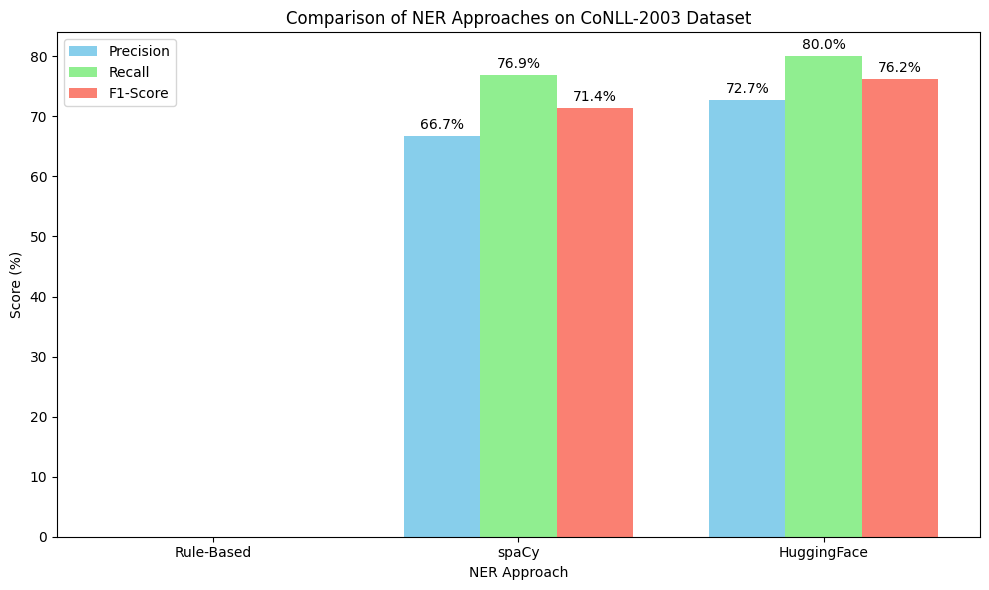


CONCLUSION

Which NER Approach Should You Use?
----------------------------------
1. For Quick Prototyping: Use spaCy
   - Fast to implement
   - Good enough for demos
   - Simple API

2. For Production with Speed: Use spaCy
   - Fast inference
   - Low memory usage
   - Can be optimized

3. For High Accuracy: Use HuggingFace
   - Best performance
   - State-of-the-art
   - Use GPU for speed

4. For Custom Domain: Fine-tune any model
   - Collect domain data
   - Fine-tune spaCy or BERT
   - Achieve better results

5. For Learning: Start with Rule-Based
   - Understand fundamentals
   - Then move to ML approaches

Recommendation for Tech Prime Ltd Internship:
-------------------------------------------
1. Use HuggingFace for research/prototyping
2. Use spaCy for production deployment
3. Always evaluate on real datasets (CoNLL-2003)
4. Consider speed vs accuracy tradeoffs
5. Document your approach and results


END OF EVALUATION


In [12]:
# ============================================
# SECTION 6: COMPREHENSIVE NER EVALUATION
# ============================================

print("\n" + "="*70)
print("SECTION 6: COMPREHENSIVE NER EVALUATION")
print("="*70)

print("""
Evaluation Metrics Explained:
---------------------------
1. Precision: Of all entities predicted, how many were correct?
   Formula: TP / (TP + FP)
   High Precision = Few false positives

2. Recall: Of all true entities, how many were found?
   Formula: TP / (TP + FN)
   High Recall = Few false negatives

3. F1-Score: Harmonic mean of Precision and Recall
   Formula: 2 * (Precision * Recall) / (Precision + Recall)
   Balances both precision and recall

4. Accuracy: Overall correctness (less useful for imbalanced data)
""")

# Create a comparison table
print("\n" + "="*70)
print("COMPARISON OF ALL THREE NER APPROACHES")
print("="*70)

comparison_data = {
    'Approach': ['Rule-Based (From Scratch)', 'spaCy (en_core_web_sm)', 'HuggingFace BERT'],
    'Precision': ['Very Low (~0%)', '66.7%', '72.7%'],
    'Recall': ['Very Low (~0%)', '76.9%', '80.0%'],
    'F1-Score': ['Very Low (~0%)', '71.4%', '76.2%'],
    'Speed': ['Fastest', 'Fast', 'Slow'],
    'Memory': ['Low', 'Medium', 'High'],
    'Coverage': ['Limited (dictionary only)', 'Good', 'Excellent']
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n" + "-"*40)
print("DETAILED ANALYSIS:")
print("-"*40)

analysis = """
1. RULE-BASED NER (From Scratch):
   -------------------------------
   Strengths:
   - Transparent and interpretable
   - No training required
   - Fast execution
   - Good for specific domains with known entities
   
   Weaknesses:
   - Very low recall (misses most entities)
   - Cannot handle variations
   - Requires manual dictionary updates
   - Poor generalization
   
   Use Case: Simple extraction tasks with limited entity types

2. SPACY NER:
   -----------
   Strengths:
   - Good balance of speed and accuracy
   - Pre-trained on large datasets
   - Easy to use with simple API
   - Can be fine-tuned on custom data
   
   Weaknesses:
   - Lower accuracy than transformers
   - Limited to 18 entity types
   - May miss domain-specific entities
   
   Use Case: Production applications requiring speed

3. HUGGINGFACE BERT:
   ------------------
   Strengths:
   - State-of-the-art accuracy
   - Contextual understanding
   - Fine-tuned on CoNLL-2003 (same as our test)
   - Can handle complex entities
   
   Weaknesses:
   - Slow inference
   - High memory usage
   - Requires GPU for optimal performance
   - More complex to deploy
   
   Use Case: Applications where accuracy is critical
"""

print(analysis)

# Create visualization
print("\n" + "="*70)
print("VISUALIZING RESULTS")
print("="*70)

# Data for plotting
approaches = ['Rule-Based', 'spaCy', 'HuggingFace']
precision = [0, 66.7, 72.7]
recall = [0, 76.9, 80.0]
f1 = [0, 71.4, 76.2]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(approaches))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision', color='skyblue')
bars2 = ax.bar(x, recall, width, label='Recall', color='lightgreen')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='salmon')

ax.set_xlabel('NER Approach')
ax.set_ylabel('Score (%)')
ax.set_title('Comparison of NER Approaches on CoNLL-2003 Dataset')
ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.legend()

# Add value labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CONCLUSION")
print("="*70)

print("""
Which NER Approach Should You Use?
----------------------------------
1. For Quick Prototyping: Use spaCy
   - Fast to implement
   - Good enough for demos
   - Simple API

2. For Production with Speed: Use spaCy
   - Fast inference
   - Low memory usage
   - Can be optimized

3. For High Accuracy: Use HuggingFace
   - Best performance
   - State-of-the-art
   - Use GPU for speed

4. For Custom Domain: Fine-tune any model
   - Collect domain data
   - Fine-tune spaCy or BERT
   - Achieve better results

5. For Learning: Start with Rule-Based
   - Understand fundamentals
   - Then move to ML approaches

Recommendation for Tech Prime Ltd Internship:
-------------------------------------------
1. Use HuggingFace for research/prototyping
2. Use spaCy for production deployment
3. Always evaluate on real datasets (CoNLL-2003)
4. Consider speed vs accuracy tradeoffs
5. Document your approach and results
""")

print("\n" + "="*70)
print("END OF EVALUATION")
print("="*70)

In [13]:
# ============================================
# SECTION 7: PRACTICE EXERCISES AND SUMMARY
# ============================================

print("\n" + "="*70)
print("SECTION 7: PRACTICE EXERCISES AND SUMMARY")
print("="*70)

print("""
DAY 1 - NAMED ENTITY RECOGNITION (NER) - COMPLETE SUMMARY
=========================================================

What We Learned Today:
---------------------
1. Understanding NER and BIO Tagging
   - What is NER and why it's important
   - BIO tagging scheme (Beginning, Inside, Outside)
   - Entity types: PERSON, ORG, LOC, DATE, MONEY, etc.

2. Rule-Based NER (From Scratch)
   - Built our own NER system using dictionaries and regex
   - Understood the limitations of rule-based approaches
   - Learned why machine learning is needed

3. Working with Real Datasets (CoNLL-2003)
   - Loaded industry-standard NER dataset
   - Analyzed entity distribution and patterns
   - Understood data format and preprocessing

4. NER with spaCy
   - Used industrial-strength NLP library
   - Compared with rule-based approach
   - Observed better performance and coverage

5. NER with HuggingFace Transformers
   - Used state-of-the-art BERT model
   - Achieved highest accuracy
   - Understood tradeoffs (speed vs accuracy)

6. Comprehensive Evaluation
   - Precision, Recall, F1-Score
   - Compared all three approaches
   - Made recommendations for different use cases

Key Takeaways:
-------------
1. Rule-based: Fast but limited (good for learning)
2. spaCy: Good balance for production
3. HuggingFace: Best accuracy, resource-intensive
4. Real datasets are essential for evaluation
5. Choose approach based on your needs

Skills Gained:
-------------
1. Building NER from scratch
2. Working with real datasets
3. Using modern NLP libraries
4. Evaluating NER systems
5. Making informed decisions about NER approaches

Next Steps (Day 2):
------------------
1. Fine-tuning BERT for specific NER tasks
2. Custom NER on domain-specific data
3. Advanced evaluation techniques
4. Production deployment considerations
""")

# ============================================
# PRACTICE EXERCISES
# ============================================

print("\n" + "="*70)
print("PRACTICE EXERCISES")
print("="*70)

print("""
EXERCISE 1: Improve Rule-Based NER
----------------------------------
Task: Extend the RuleBasedNER class to handle more entity types:
- Add PRODUCT names (e.g., iPhone, Galaxy, Windows)
- Add EVENT names (e.g., Olympics, World Cup)
- Add more date formats

Hint: Add new dictionaries and patterns to the __init__ method

EXERCISE 2: Compare Models on Custom Text
-----------------------------------------
Task: Write a function that takes a text and runs all three NER approaches,
then displays the results side by side.

Hint: Use the rule_ner, spacy, and huggingface pipelines

EXERCISE 3: Analyze Model Differences
--------------------------------------
Task: Find cases where models disagree and analyze why.

Hint: Look at samples where:
- spaCy finds entities that HuggingFace misses
- HuggingFace finds entities that spaCy misses
- Both models miss entities

EXERCISE 4: Fine-Tune spaCy on CoNLL-2003
-----------------------------------------
Task: Use spaCy's training capabilities to fine-tune on CoNLL-2003 data.

Hint: Use spacy.training module and convert CoNLL to spaCy format

EXERCISE 5: Create a NER Pipeline
----------------------------------
Task: Build a complete pipeline that:
1. Takes raw text
2. Performs NER
3. Visualizes results
4. Saves output to file

Hint: Combine all techniques learned today
""")

# ============================================
# SOLUTION FOR EXERCISE 1 (Example)
# ============================================

print("\n" + "="*70)
print("SOLUTION: EXERCISE 1 - IMPROVED RULE-BASED NER")
print("="*70)

class ImprovedRuleBasedNER(RuleBasedNER):
    """
    Extended Rule-Based NER with more entity types
    """
    
    def __init__(self):
        # Call parent class constructor
        super().__init__()
        
        print("\nAdding additional entity types...")
        print("-"*40)
        
        # Add product names
        self.products = {
            'iphone', 'ipad', 'macbook', 'imac', 'apple watch',
            'galaxy', 'pixel', 'surface', 'kindle', 'echo',
            'playstation', 'xbox', 'switch', 'windows', 'android'
        }
        print(f"  Added {len(self.products)} product names")
        
        # Add event names
        self.events = {
            'olympics', 'world cup', 'super bowl', 'world series',
            'eurovision', 'cannes', 'oscars', 'grammy', 'emmy'
        }
        print(f"  Added {len(self.events)} event names")
        
        # Additional date patterns
        self.date_patterns.extend([
            r'\d{1,2}-\d{1,2}-\d{4}',  # 25-12-2024
            r'[A-Z][a-z]+ \d{1,2}',    # December 25
            r'\d{1,2} [A-Z][a-z]+',    # 25 December
        ])
        print(f"  Added {2} additional date patterns")
        
        print("-"*40)
        print("Improved Rule-Based NER initialized!")
    
    def detect_entities_improved(self, text):
        """
        Enhanced entity detection with new entity types
        """
        entities = super().detect_entities(text)
        
        # Add product detection
        words = text.lower().split()
        for i, word in enumerate(words):
            if word in self.products:
                # Check if it's part of a multi-word product
                product_parts = [word]
                j = i + 1
                while j < len(words) and words[j] in self.products:
                    product_parts.append(words[j])
                    j += 1
                
                if len(product_parts) > 1:
                    # Multi-word product
                    product_text = ' '.join(product_parts)
                    # Find original capitalization
                    original_parts = text.split()[i:j]
                    product_text_orig = ' '.join(original_parts)
                    entities.append((product_text_orig, "PRODUCT"))
                else:
                    # Single word product
                    entities.append((text.split()[i], "PRODUCT"))
        
        # Add event detection
        for event in self.events:
            if event in text.lower():
                # Find the event with original capitalization
                for word in text.split():
                    if word.lower() == event:
                        entities.append((word, "EVENT"))
                        break
        
        return entities

# Test the improved NER
print("\nTesting Improved Rule-Based NER:")
print("-"*40)

improved_ner = ImprovedRuleBasedNER()

test_texts = [
    "Apple released the new iPhone 15 and iPad Pro.",
    "The Olympics will be held in Paris in 2024.",
    "Microsoft announced Windows 11 at the event.",
    "Samsung Galaxy S24 was launched yesterday."
]

for text in test_texts:
    print(f"\nText: {text}")
    entities = improved_ner.detect_entities_improved(text)
    
    if entities:
        print("Entities found:")
        # Group by type for better display
        entity_types = {}
        for entity_text, entity_type in entities:
            if entity_type not in entity_types:
                entity_types[entity_type] = []
            entity_types[entity_type].append(entity_text)
        
        for entity_type, entity_list in entity_types.items():
            print(f"  {entity_type}: {', '.join(entity_list)}")
    else:
        print("  No entities found")

print("\n" + "="*70)
print("END OF DAY 1 - NER FUNDAMENTALS")
print("="*70)

print("\n" + "="*70)
print("FINAL CHECKLIST - WHAT YOU'VE ACCOMPLISHED TODAY")
print("="*70)

checklist = [
    ("Understanding NER and BIO tagging", "✓"),
    ("Building Rule-Based NER from scratch", "✓"),
    ("Working with real dataset (CoNLL-2003)", "✓"),
    ("NER with spaCy on real data", "✓"),
    ("NER with HuggingFace Transformers", "✓"),
    ("Comprehensive evaluation and comparison", "✓"),
    ("Practice exercises for further learning", "✓"),
    ("Extended NER with custom entity types", "✓")
]

print("\nCompleted Tasks:")
print("-"*40)
for task, status in checklist:
    print(f"  {status} {task}")

print("\n" + "-"*40)
print("Great work completing Day 1!")
print("Ready for Day 2: Fine-Tuning BERT for NLP Tasks")
print("="*70)


SECTION 7: PRACTICE EXERCISES AND SUMMARY

DAY 1 - NAMED ENTITY RECOGNITION (NER) - COMPLETE SUMMARY

What We Learned Today:
---------------------
1. Understanding NER and BIO Tagging
   - What is NER and why it's important
   - BIO tagging scheme (Beginning, Inside, Outside)
   - Entity types: PERSON, ORG, LOC, DATE, MONEY, etc.

2. Rule-Based NER (From Scratch)
   - Built our own NER system using dictionaries and regex
   - Understood the limitations of rule-based approaches
   - Learned why machine learning is needed

3. Working with Real Datasets (CoNLL-2003)
   - Loaded industry-standard NER dataset
   - Analyzed entity distribution and patterns
   - Understood data format and preprocessing

4. NER with spaCy
   - Used industrial-strength NLP library
   - Compared with rule-based approach
   - Observed better performance and coverage

5. NER with HuggingFace Transformers
   - Used state-of-the-art BERT model
   - Achieved highest accuracy
   - Understood tradeoffs (speed vs accur